Task 1:Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task 2:upload the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Employee data.csv to Employee data.csv


Task 3:Display First 5 Rows

In [4]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Employee data.csv']))
df.head()

,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No


Task 4:Check Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        474 non-null    float64
 1   gender    474 non-null    object 
 2   bdate     473 non-null    object 
 3   educ      474 non-null    int64  
 4   jobcat    474 non-null    object 
 5   salary    474 non-null    float64
 6   salbegin  474 non-null    float64
 7   jobtime   474 non-null    float64
 8   prevexp   474 non-null    object 
 9   minority  474 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 37.2+ KB


Task 5:Check Missing Values

In [6]:
df.isnull().sum()

,0
id,0
gender,0
bdate,1
educ,0
jobcat,0
salary,0
salbegin,0
jobtime,0
prevexp,0
minority,0


Task 6:Remove Duplicates Records

In [7]:
df.drop_duplicates(inplace=True)

Task 6.1:check duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Task 7:Fill Missing Values

Task 7.1:For numerical columns

In [10]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Task 7.2:for Categorical columns

In [11]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1227/3991344066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Task 8:Detect Outilers

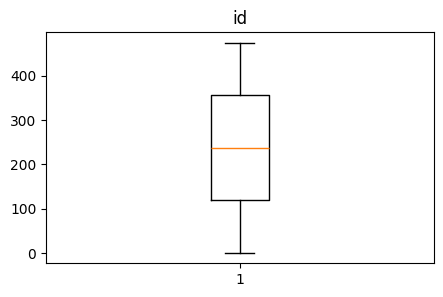

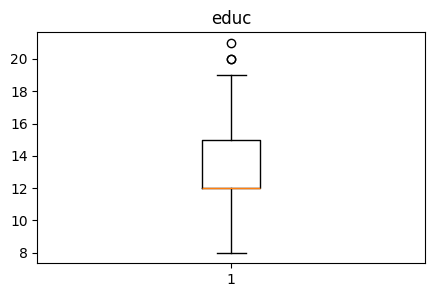

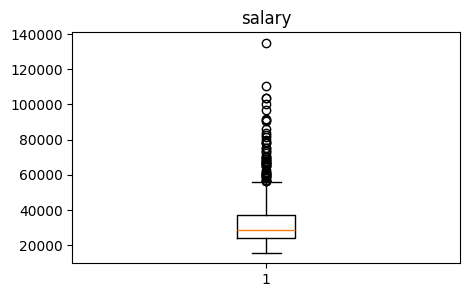

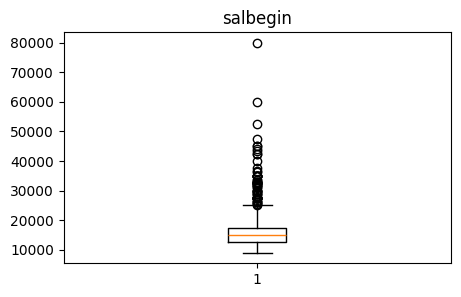

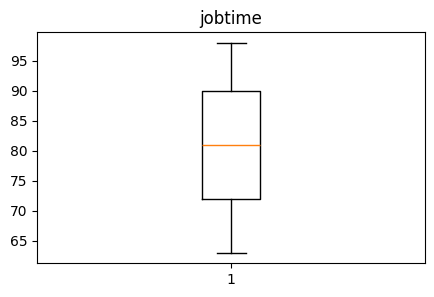

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

Task 9:Remove Outilers

In [13]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Task 10:Summary statistics

In [14]:
df.describe()

,id,educ,salary,salbegin,jobtime
count,396.000000,396.000000,396.000000,396.000000,396.000000
mean,239.025253,12.724747,28159.356061,14188.648990,81.040404
std,136.698965,2.420899,6980.442409,2684.199431,10.057978
min,2.000000,8.000000,15750.000000,9000.000000,63.000000
25%,121.750000,12.000000,23100.000000,12000.000000,72.000000
50%,240.000000,12.000000,27225.000000,14250.000000,81.000000
75%,358.250000,15.000000,31387.500000,15750.000000,90.000000
max,474.000000,19.000000,54000.000000,21240.000000,98.000000


Task 11:Visualization 1-Histogram

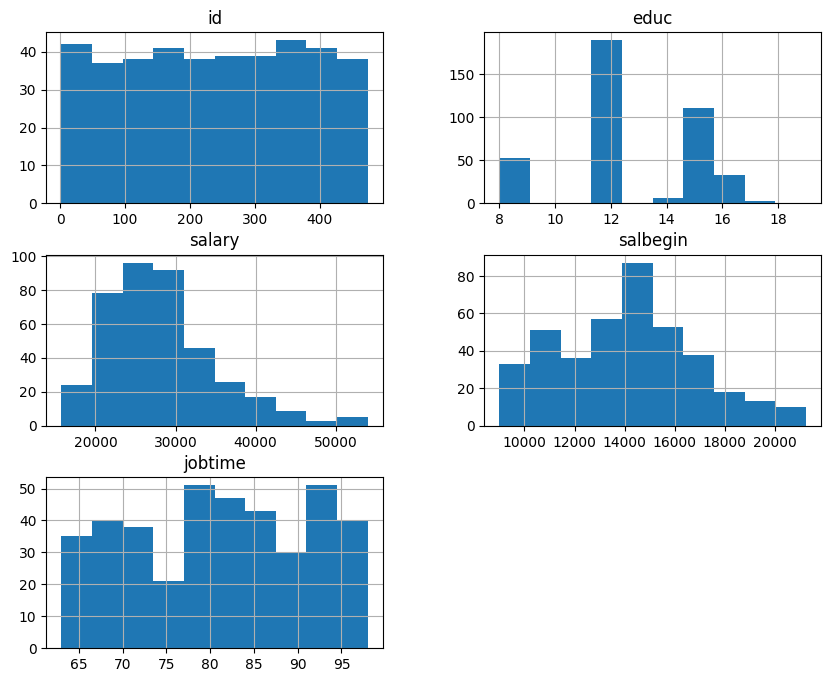

In [15]:
df.hist(figsize=(10,8))
plt.show()

Task 12:Visualization 2-Bar chart

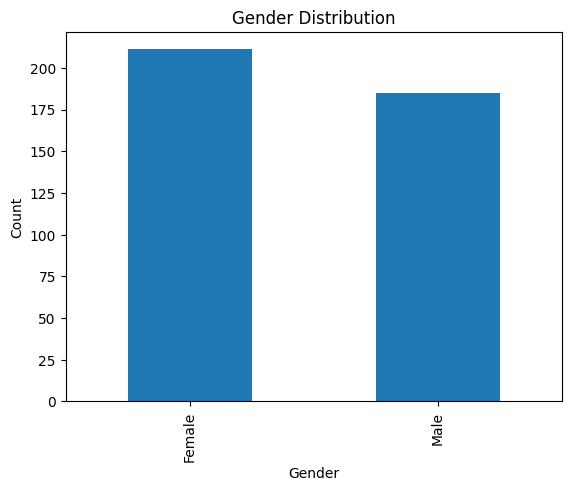

In [17]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Task 13:Visualization 3-pie chart

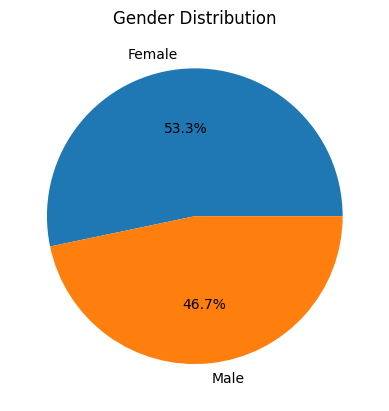

In [19]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Task 13:Visualization 4- Scattor plot

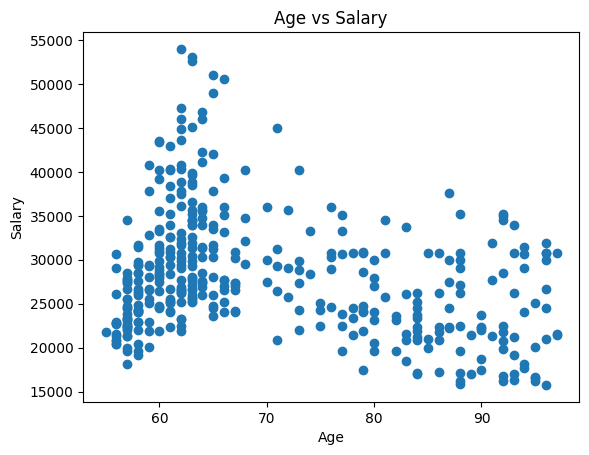

In [21]:
from datetime import datetime

df['bdate'] = pd.to_datetime(df['bdate'])
current_year = datetime.now().year
df['Age'] = current_year - df['bdate'].dt.year

plt.scatter(df['Age'], df['salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

Task 14:Save cleaned dataset

In [22]:
df.to_csv('Cleaned_Employee_Data.csv', index=False)

In [23]:
from google.colab import files
files.download('Cleaned_Employee_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>